# 노트북 3 — 스파이크 인코더 4종 (E1~E4)

**EEG Resonate Encoding SNN 프로젝트** · 노트북 3

E1(Rate+GRF)·E2(다중임계 Delta)·E3(필터뱅크+Delta, 통제군)·E4(Resonate, 제안)를 구현하고
출력 형태를 (T, B, C=9, N=8)로 통일한다. E3와 E4는 같은 지수윈도 STFT 선형 recursion을 공유하고
스파이크 생성 규칙만 다르게 해, 둘의 차이가 비선형 부분(스파이크 규칙)에서만 나오도록 한다(CLAUDE.md 2, 3절).

### 학습 목표
- E1~E4 인코더를 구현하고 출력 형태가 모두 (T,B,C,N)=(192,B,9,8)로 같은지 확인한다.
- 합성 사인파로 Resonate 뉴런의 내부 상태가 진동하고 구동 주파수 근처에서 진폭이 커짐을 확인한다.
- 실제 EEG 시행 하나에 네 인코더를 다 적용해 래스터 플롯으로 비교한다.
- 인코더별 시행당 평균 스파이크 수를 집계해 극단적으로 적거나(0에 가깜움) 과도하지(거의 모두 발화) 않는지 확인한다.


## 1. 설치와 임포트

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import koreanize_matplotlib          # 그래프 한글 폰트

torch.manual_seed(0)                 # 재현성 (E1의 베르누이 발화용)


## 2. 파라미터 설정

E1~E4 모두 출력 차원을 8로 통일한다(CLAUDE.md 3절). E3/E4의 공진주파수는 정렬 조건(8–30 Hz 로그 배치)을 기본값으로 쓴다.
임계값은 실제 EEG 배치로 스파이크 수를 확인해가며 조정한 값이다(CLAUDE.md 지침: 스파이크가 거의 0이거나 과도하면 threshold 조정).

In [2]:
NUM_STEPS = 192                  # 노트북 1과 동일 (T)
N_DIMS = 8                       # 인코더 출력 채널(주파수/구간) 수
FS = 128                         # 샘플링 주파수 [Hz]
DECAY = 0.9                      # 공진/필터 감쇠율 (E3, E4 공용)

GRF_RANGE = (-3.0, 3.0)          # E1: z-score 값 범위
GRF_SIGMA_SCALE = 1.2            # E1: 가우시안 폭 배율
E2_THRESHOLDS = torch.tensor([0.1, 0.3, 0.6, 1.0])   # E2: 변화량 임계값 4단계 (오름차순)

FREQS_ALIGNED = torch.logspace(
    torch.log10(torch.tensor(8.0)), torch.log10(torch.tensor(30.0)), N_DIMS
)                                 # E3, E4: 정렬 배치 공진주파수 8개 (8-30 Hz 로그)
E3_THRESHOLD = 1.5                # E3: 필터뱅크 delta 임계값
E4_THRESHOLD = 0.8                # E4: Resonate 진폭 임계값

print('정렬 배치 공진주파수:', [round(f, 2) for f in FREQS_ALIGNED.tolist()])


정렬 배치 공진주파수: [8.0, 9.66, 11.67, 14.1, 17.03, 20.56, 24.84, 30.0]


## 3. E1 (Rate + 가우시안 수용장, GRF), E2 (다중임계 Delta)

E1은 각 시점의 z-score 값을 8개 가우시안 수용장 중심에 비교해 반응률을 구하고, 그 확률로 베르누이 발화시킨다(3장 스파이크 인코딩과 같은 방식).
E2는 변화량이 4단계 임계값(상승용 4개 + 하강용 4개 = 8차원)을 넘을 때만 불리언 산술로 발화한다(if 없이).

In [3]:
def encode_rate_grf(signal, num_neurons=N_DIMS, sigma_scale=GRF_SIGMA_SCALE, value_range=GRF_RANGE):
    # signal: (B,C,T) — z-score 값
    centers = torch.linspace(value_range[0], value_range[1], num_neurons)              # (N,) 수용장 중심
    sigma = (value_range[1] - value_range[0]) / num_neurons * sigma_scale              # 가우시안 폭

    x = signal[:, :, None, :]                                                          # (B,C,1,T)
    response = torch.exp(-((x - centers[None, None, :, None]) ** 2) / (2 * sigma ** 2))  # (B,C,N,T)
    spk = torch.bernoulli(response)                                                    # 반응률로 베르누이 발화
    return spk.permute(3, 0, 1, 2)                                                      # (T,B,C,N)


def encode_delta_multi(signal, thresholds=E2_THRESHOLDS):
    # signal: (B,C,T)
    delta = signal[:, :, 1:] - signal[:, :, :-1]
    delta = torch.cat([torch.zeros_like(delta[:, :, :1]), delta], dim=2)               # 첫 스텝 변화량 0
    pos = delta[:, :, None, :]                                                          # (B,C,1,T)
    thr = thresholds[None, None, :, None]                                              # (1,1,4,1)

    spk_pos = (pos > thr).float()                                                      # 상승 임계 4단계
    spk_neg = (pos < -thr).float()                                                     # 하강 임계 4단계
    spk = torch.cat([spk_pos, spk_neg], dim=2)                                         # (B,C,8,T)
    return spk.permute(3, 0, 1, 2)                                                      # (T,B,C,N)


## 4. E3 (지수윈도 STFT 필터벅크 + Delta), E4 (Resonate)

E3, E4는 동일한 선형 recursion(`resonate_linear_state`)을 공유한다 — RF 뉴런의 역치하 동역학과 수학적으로 동일한 지수윈도 STFT다(CLAUDE.md 2절).
E3는 이 실수부(u)에 델타 변조를 적용해 발화하고(통제군), E4는 CLAUDE.md 참조 구현대로 허수부 상향 영교차 + 실수부 임계 초과로 발화한다(제안).
둘의 차이는 이 스파이크 규칙 하나뿐이다.

In [4]:
def resonate_linear_state(signal, freqs, fs, decay):
    # E3, E4가 공유하는 선형 부분 — 지수 윈도우 STFT recursion
    omega = 2 * torch.pi * freqs / fs                          # 스텝당 위상 증가량
    cos_w, sin_w = torch.cos(omega), torch.sin(omega)
    u = torch.zeros(signal.size(0), freqs.numel(), signal.size(1))   # 실수부
    v = torch.zeros_like(u)                                           # 허수부
    u_rec, v_rec = [], []

    for step in range(signal.size(2)):
        x = signal[:, None, :, step]                                  # (B,1,C)
        u_next = decay * (cos_w[:, None] * u - sin_w[:, None] * v) + x
        v_next = decay * (sin_w[:, None] * u + cos_w[:, None] * v)
        u, v = u_next, v_next
        u_rec.append(u)
        v_rec.append(v)

    return torch.stack(u_rec), torch.stack(v_rec)                     # 각 (T,B,F,C)


def encode_filterbank_delta(u_rec, threshold=E3_THRESHOLD):
    # E3: 필터뱅크 실수부(u)에 델타 변조 적용 (통제군)
    delta = u_rec[1:] - u_rec[:-1]
    delta = torch.cat([torch.zeros_like(delta[:1]), delta], dim=0)
    spk = (delta.abs() > threshold).float()                           # (T,B,F,C)
    return spk.permute(0, 1, 3, 2)                                     # (T,B,C,F)


def encode_resonate(u_rec, v_rec, threshold=E4_THRESHOLD):
    # E4: 허수부 상향 영교차 + 실수부 임계 초과 (제안)
    v_prev = torch.cat([torch.zeros_like(v_rec[:1]), v_rec[:-1]], dim=0)
    spk = (v_prev <= 0).float() * (v_rec > 0).float() * (u_rec > threshold).float()
    return spk.permute(0, 1, 3, 2)                                     # (T,B,C,F)


## 5. 합성 사인파로 Resonate 뉴런 검증

EEG 없이 10 Hz 순수 사인파를 넣어, 각 공진주파수 채널의 정상상태 진폭(허수부·실수부 크기)을 확인한다.
구동 주파수(10 Hz)에 가장 가까운 공진주파수 채널에서 진폭이 가장 커야 정상이다.

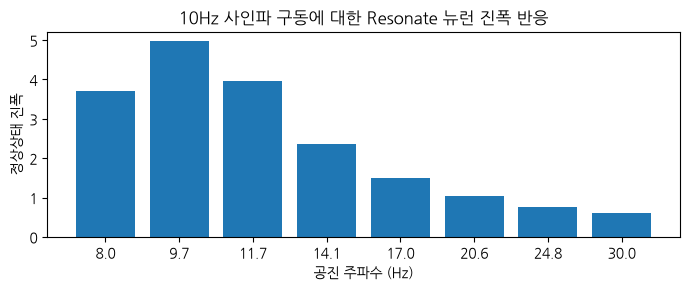

진폭이 가장 큰 공진 주파수: 9.66 Hz (구동 주파수 10Hz에 근접해야 정상)


In [5]:
t = torch.arange(NUM_STEPS).float() / FS
sine_signal = torch.sin(2 * torch.pi * 10.0 * t)[None, None, :]        # 10Hz 순수 사인파 (B=1,C=1,T)

u_rec_syn, v_rec_syn = resonate_linear_state(sine_signal, FREQS_ALIGNED, FS, DECAY)
amp_syn = torch.sqrt(u_rec_syn ** 2 + v_rec_syn ** 2)                    # (T,1,F,1) 진폭
steady_amp = amp_syn[100:].mean(dim=0)[0, :, 0]                          # 정상상태(뒷부분) 평균 진폭

plt.figure(figsize=(7, 3))
plt.bar([f'{f:.1f}' for f in FREQS_ALIGNED.tolist()], steady_amp.tolist(), color='tab:blue')
plt.xlabel('공진 주파수 (Hz)'); plt.ylabel('정상상태 진폭')
plt.title('10Hz 사인파 구동에 대한 Resonate 뉴런 진폭 반응')
plt.tight_layout(); plt.show()

peak_freq = FREQS_ALIGNED[steady_amp.argmax()].item()
print(f'진폭이 가장 큰 공진 주파수: {peak_freq:.2f} Hz (구동 주파수 10Hz에 근접해야 정상)')


## 6. 실제 EEG 데이터에 4종 인코더 적용

노트북 1이 저장한 에폭 데이터에 E1~E4를 모두 적용해 출력 형태가 동일한지 확인한다.

In [6]:
npz = np.load('../data/processed/eeg_epochs.npz')
X = npz['X']                                        # (시행, 채널, 시간)
y = npz['y']
CHANNELS = list(npz['channels'])
signal = torch.tensor(X, dtype=torch.float32)

spk_e1 = encode_rate_grf(signal)
spk_e2 = encode_delta_multi(signal)
u_rec, v_rec = resonate_linear_state(signal, FREQS_ALIGNED, FS, DECAY)
spk_e3 = encode_filterbank_delta(u_rec)
spk_e4 = encode_resonate(u_rec, v_rec)

print('E1 출력 형태:', tuple(spk_e1.shape))
print('E2 출력 형태:', tuple(spk_e2.shape))
print('E3 출력 형태:', tuple(spk_e3.shape))
print('E4 출력 형태:', tuple(spk_e4.shape))


E1 출력 형태: (192, 450, 9, 8)
E2 출력 형태: (192, 450, 9, 8)
E3 출력 형태: (192, 450, 9, 8)
E4 출력 형태: (192, 450, 9, 8)


## 7. 래스터 플롯 비교

한 시행의 C3 채널에서 네 인코더의 스파이크 패턴을 나란히 비교한다.

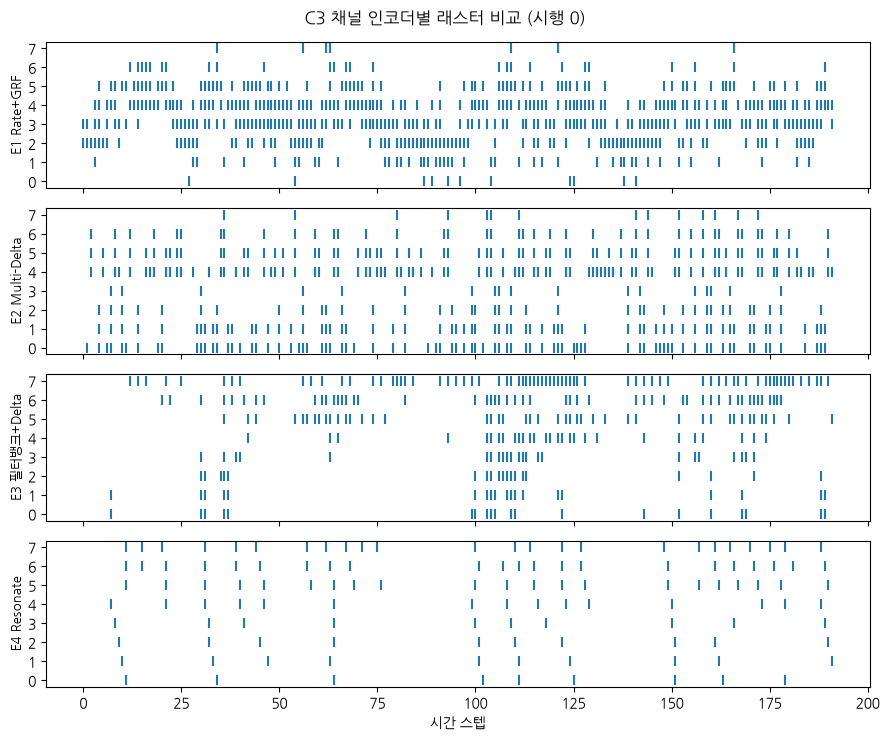

In [7]:
trial_idx = 0
c3_idx = CHANNELS.index('C3')
encoders = {
    'E1 Rate+GRF': spk_e1,
    'E2 Multi-Delta': spk_e2,
    'E3 필터뱅크+Delta': spk_e3,
    'E4 Resonate': spk_e4,
}

fig, axs = plt.subplots(4, 1, figsize=(9, 7.5), sharex=True)
for ax, (name, spk) in zip(axs, encoders.items()):
    spk_trial = spk[:, trial_idx, c3_idx, :]                       # (T,N)
    for n in range(N_DIMS):
        spike_times = torch.where(spk_trial[:, n] > 0)[0].numpy()
        ax.scatter(spike_times, [n] * len(spike_times), marker='|', s=60, color='tab:blue')
    ax.set_ylabel(name, fontsize=9)
    ax.set_yticks(range(N_DIMS))

axs[-1].set_xlabel('시간 스텝')
fig.suptitle(f'C3 채널 인코더별 래스터 비교 (시행 {trial_idx})')
plt.tight_layout(); plt.show()


## 8. 스파이크 수 집계

인코더별 시행당 평균 총 스파이크 수를 비교한다(시간·채널·차원 축 모두 합산).

E1 Rate+GRF: 시행당 평균 4497.8 스파이크 (전체 13824칸 중 32.5%)
E2 Multi-Delta: 시행당 평균 3135.5 스파이크 (전체 13824칸 중 22.7%)
E3 필터뱅크+Delta: 시행당 평균 2176.0 스파이크 (전체 13824칸 중 15.7%)
E4 Resonate: 시행당 평균 916.3 스파이크 (전체 13824칸 중 6.6%)


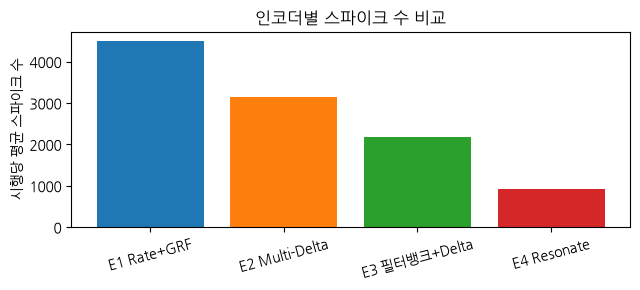

In [8]:
mean_counts = {
    'E1 Rate+GRF': spk_e1.sum(dim=(0, 2, 3)).mean().item(),
    'E2 Multi-Delta': spk_e2.sum(dim=(0, 2, 3)).mean().item(),
    'E3 필터뱅크+Delta': spk_e3.sum(dim=(0, 2, 3)).mean().item(),
    'E4 Resonate': spk_e4.sum(dim=(0, 2, 3)).mean().item(),
}

for name, count in mean_counts.items():
    total_possible = NUM_STEPS * len(CHANNELS) * N_DIMS
    print(f'{name}: 시행당 평균 {count:.1f} 스파이크 (전체 {total_possible}칸 중 {count/total_possible*100:.1f}%)')

plt.figure(figsize=(6.5, 3))
plt.bar(mean_counts.keys(), mean_counts.values(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.ylabel('시행당 평균 스파이크 수')
plt.title('인코더별 스파이크 수 비교')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


## 정리

- E1(Rate+GRF), E2(다중임계 Delta), E3(필터벅크+Delta), E4(Resonate) 모두 출력 형태 (T,B,C,N)=(192,B,9,8)로 통일해서 구현했다.
- E3, E4는 같은 지수윈도 STFT 선형 recursion(`resonate_linear_state`)을 공유하고, 스파이크 생성 규칙만 다르게 해 둘의 차이를 비선형 부분으로 좌혔다.
- 10Hz 합성 사인파 검증에서 Resonate 뉴런의 정상상태 진펭이 구동 주파수와 가장 가까운 공진주파수 채널에서 가장 커짐을 확인했다.
- 실제 EEG 에폭에 네 인코더를 모두 적용해 래스터 패턴과 시행당 평균 스파이크 수를 확인했다. 어느 인코더도 거의 0이거나 과도하게 발화하지 않았다.

다음 노트북(04_train_compare)에서는 이 4개 인코더(+대역 배치 절제)를 CSNN에 넣어 60회 학습하고 정확도·스파이크 수를 비교한다.